# 4.7 Les PINN (réseaux de neurones informés par la physique)

## 1. Introduction

Les *physics-informed neural networks* (PINN, réseaux de neurones informés par la physique) intègrent des lois physiques, exprimées comme des équations différentielles ordinaires ou aux dérivées partielles (EDO/EDP), directement dans l'entraînement d'un réseau de neurones. La physique entre par la fonction de perte : en plus d'ajuster les données, le réseau est pénalisé quand ses prédictions violent l'équation qui gouverne le problème. Les PINN permettent :

* de résoudre des équations différentielles avec ou sans données,
* de travailler avec peu d'échantillons étiquetés, parce que la physique contraint la solution,
* d'incorporer des connaissances a priori dans un flux de travail d'apprentissage automatique.

Les géosciences regorgent de processus gouvernés par des équations bien connues : diffusion de la chaleur dans la croûte, propagation des ondes sismiques, écoulement souterrain (loi de Darcy) et dynamique des fluides (Navier-Stokes). Les PINN ont été introduits par Raissi et al. (2019) et présentés à l'ensemble de la communauté physicienne par Karniadakis et al. (2021) ; voir les références à la fin de ce carnet. Exemples d'usage en géosciences :

1. **Diffusion de la température dans la croûte :** inférer la structure thermique et le potentiel géothermique à partir de profils de température de forage épars.
2. **Propagation des ondes sismiques :** résoudre les équations d'onde en milieu hétérogène sans mailler le domaine.
3. **Écoulement souterrain :** résoudre les équations de Darcy et d'advection-diffusion pour modéliser la réponse d'un aquifère et le transport de polluants.

Dans les trois cas, l'attrait est le même : les données de terrain sont éparses et bruitées, mais l'EDP qui gouverne le problème est connue. La physique comble là où les données ne peuvent pas.

🖥️ [**Diapositives du cours — Séance 26 (mer. 2 déc., contexte d'enrichissement)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec26_forecasting.html)

## 2. Cadre mathématique

Un PINN comporte trois composantes :

1. **Un réseau de neurones** $u_\theta(x, t)$ de paramètres $\theta$ qui approche la solution $u(x, t)$.
2. **Une équation gouvernante** écrite sous forme de résidu $\mathcal{L}(u, x, t) = 0$, où $\mathcal{L}$ est un opérateur différentiel. Les dérivées de $u_\theta$ qui apparaissent dans $\mathcal{L}$ sont calculées exactement par différentiation automatique, la machinerie même qu'emploie la rétropropagation.
3. **Une fonction de perte composite**

$$
\text{Loss} = \text{Data loss} + \text{Physics loss} + \text{Initial/boundary condition loss},
$$

où

* la perte de données mesure l'écart aux observations,
* la perte physique est le résidu quadratique moyen de l'EDP $\mathcal{L}(u_\theta)$ évalué en des *points de collocation* tirés à l'intérieur du domaine,
* la perte de conditions initiales et aux limites fixe la solution là où elle est connue.

L'entraînement minimise la perte combinée avec un optimiseur à base de gradient comme Adam. Les poids relatifs des trois termes sont des hyperparamètres, et les équilibrer est l'une des difficultés pratiques des PINN (nous y revenons à la section 5).

In [1]:
import functools
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
# PINN training differentiates through gradients (double-backward autograd),
# which is most reliable on CPU, and these models are tiny: we train on CPU.
DEVICE = torch.device("cpu")
torch.set_num_threads(1)  # single thread is fastest for such small tensors

torch.manual_seed(42)
np.random.seed(10)

## 3. Échauffement : la loi de refroidissement de Newton

Avant de nous attaquer à une EDP, nous commençons par une EDO, où la différentiation automatique n'a besoin que de dérivées premières. Considérons un échantillon de roche qui se refroidit vers la température ambiante $T_{\text{env}}$. La loi de refroidissement de Newton énonce

$$
\frac{dT}{dt} = R \, (T_{\text{env}} - T),
$$

où $R$ est une constante de vitesse de refroidissement. Avec la température initiale $T(0) = T_0$, la solution analytique s'écrit

$$
T(t) = T_{\text{env}} + (T_0 - T_{\text{env}}) \, e^{-Rt}.
$$

Nous allons mener une comparaison à trois sur les mêmes 10 mesures bruitées, toutes prises tôt dans l'histoire du refroidissement :

1. un réseau de neurones simple (modèle de référence),
2. le même réseau avec une régularisation L2 des poids,
3. le même réseau avec une perte physique (un PINN).

La question est de savoir lequel extrapole correctement au-delà de la plage temporelle couverte par les données.

In [2]:
def cooling_law(time, Tenv, T0, R):
    T = Tenv + (T0 - Tenv) * np.exp(-R * time)
    return T

Nous générons des données synthétiques bruitées : la vraie courbe s'étend sur 1000 s, mais les 10 échantillons d'entraînement ne couvrent que les 300 premières secondes.

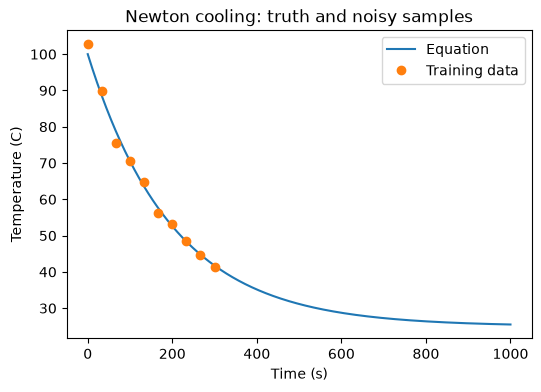

In [3]:
Tenv = 25
T0 = 100
R = 0.005
times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, 10)
T = eq(t) + 2 * np.random.randn(10)

plt.figure(figsize=(6, 4))
plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Newton cooling: truth and noisy samples')
plt.show()

### 3.1 Un réseau avec une seconde perte interchangeable

La classe `Net` ci-dessous est un petit réseau entièrement connecté. Sa méthode `fit` minimise l'écart aux données plus une seconde perte optionnelle `loss2`, pondérée par `loss2_weight`. Nous réutiliserons la même classe pour les trois expériences en ne changeant que `loss2` : `None` pour le modèle de référence, une pénalité L2 pour le réseau régularisé, et un résidu physique pour le PINN.

La fonction utilitaire `grad` calcule la dérivée des sorties du réseau par rapport aux entrées avec `torch.autograd.grad` et `create_graph=True`, de sorte que le résultat peut lui-même être dérivé lors de la rétropropagation. C'est l'astuce centrale des PINN.

In [4]:
def np_to_th(x):
    """Convert a numpy array to a float32 torch tensor of shape (n, -1)."""
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)


def grad(outputs, inputs):
    """Partial derivative of outputs with respect to inputs.

    Args:
        outputs: (N, 1) tensor
        inputs: (N, D) tensor
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )


class Net(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)
        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.2f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()

### 3.2 Réseau de référence

Entraînement sur les 10 échantillons bruités, sans terme de perte supplémentaire.

Epoch 0/2000, loss: 4713.88
Epoch 200/2000, loss: 2527.58
Epoch 400/2000, loss: 2299.78


Epoch 600/2000, loss: 1233.46
Epoch 800/2000, loss: 74.98
Epoch 1000/2000, loss: 3.04


Epoch 1200/2000, loss: 2.11
Epoch 1400/2000, loss: 1.84
Epoch 1600/2000, loss: 1.69


Epoch 1800/2000, loss: 1.57


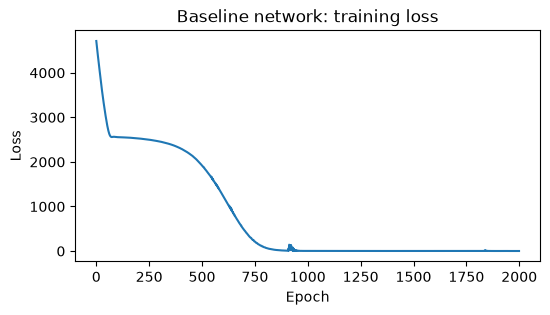

In [5]:
net = Net(1, 1, loss2=None, epochs=2000, lr=1e-4).to(DEVICE)

losses = net.fit(t, T)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline network: training loss')
plt.show()

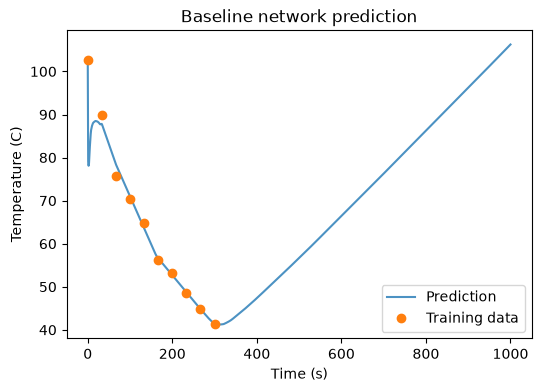

In [6]:
prediction_temp_baseline = net.predict(times)

plt.figure(figsize=(6, 4))
plt.plot(times, prediction_temp_baseline, alpha=0.8)
plt.plot(t, T, 'o')
plt.legend(['Prediction', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Baseline network prediction')
plt.show()

Le modèle de référence ajuste les échantillons qu'il a vus et fait ce qu'il veut après 300 s : rien ne contraint l'extrapolation.

### 3.3 Réseau régularisé en L2

Un remède classique au surapprentissage consiste à pénaliser les grands poids. Nous passons la norme L2 des paramètres comme `loss2`.

In [7]:
# Second loss: L2 norm of the network weights
def l2_reg(model: torch.nn.Module):
    return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Epoch 0/20000, loss: 11219.99


Epoch 2000/20000, loss: 3914.45


Epoch 4000/20000, loss: 2424.52


Epoch 6000/20000, loss: 1626.11


Epoch 8000/20000, loss: 1206.96


Epoch 10000/20000, loss: 1010.50


Epoch 12000/20000, loss: 912.78


Epoch 14000/20000, loss: 840.27


Epoch 16000/20000, loss: 775.95


Epoch 18000/20000, loss: 715.29


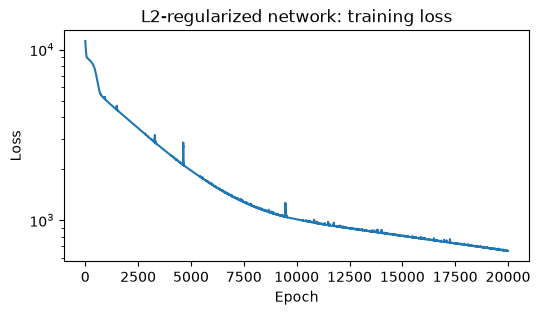

In [8]:
netreg = Net(1, 1, loss2=l2_reg, epochs=20000, lr=1e-4, loss2_weight=1).to(DEVICE)

losses = netreg.fit(t, T)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('L2-regularized network: training loss')
plt.show()

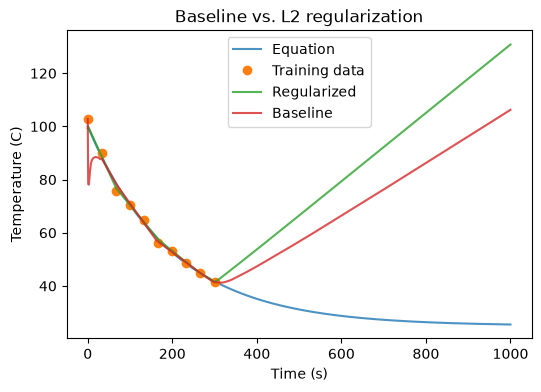

In [9]:
prediction_temp_regularized = netreg.predict(times)

plt.figure(figsize=(6, 4))
plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, prediction_temp_regularized, alpha=0.8)
plt.plot(times, prediction_temp_baseline, alpha=0.8)
plt.legend(labels=['Equation', 'Training data', 'Regularized', 'Baseline'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Baseline vs. L2 regularization')
plt.show()

La régularisation lisse la prédiction, mais elle n'a aucune raison de suivre la décroissance exponentielle vers $T_{\text{env}}$ : elle se contente de maintenir les poids petits.

### 3.4 Le PINN

Remplaçons maintenant la pénalité L2 par une perte physique. Nous évaluons le réseau en 1000 instants de collocation couvrant toute la fenêtre de 1000 s (bien au-delà des données), nous dérivons la sortie par rapport au temps avec `grad`, et nous pénalisons le résidu quadratique moyen de la loi de refroidissement

$$
r(t) = R\,(T_{\text{env}} - T_\theta(t)) - \frac{dT_\theta}{dt}.
$$

Notez que la perte physique n'utilise aucune observation de température, seulement l'équation.

In [10]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000).view(-1, 1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R * (Tenv - temps) - dT
    return torch.mean(pde**2)

Epoch 0/10000, loss: 4775.84


Epoch 1000/10000, loss: 1.04


Epoch 2000/10000, loss: 0.63


Epoch 3000/10000, loss: 1.32


Epoch 4000/10000, loss: 0.63


Epoch 5000/10000, loss: 2.21


Epoch 6000/10000, loss: 0.35


Epoch 7000/10000, loss: 0.58


Epoch 8000/10000, loss: 0.76


Epoch 9000/10000, loss: 0.66


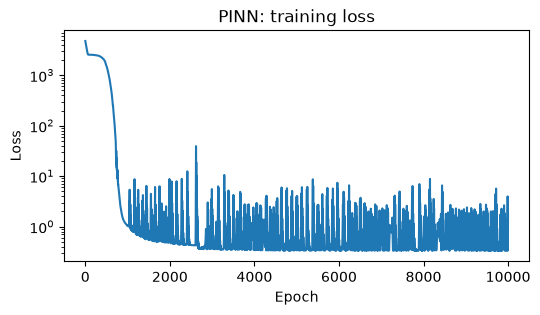

In [11]:
net_PINN = Net(1, 1, loss2=physics_loss, epochs=10000, loss2_weight=1, lr=1e-4).to(DEVICE)

losses = net_PINN.fit(t, T)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN: training loss')
plt.show()

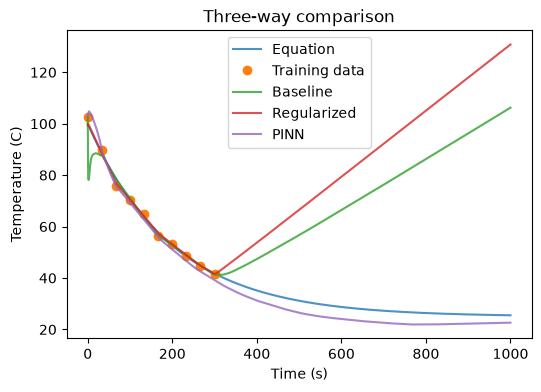

In [12]:
prediction_temp_pinn = net_PINN.predict(times)

plt.figure(figsize=(6, 4))
plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, prediction_temp_baseline, alpha=0.8)
plt.plot(times, prediction_temp_regularized, alpha=0.8)
plt.plot(times, prediction_temp_pinn, alpha=0.8)
plt.legend(labels=['Equation', 'Training data', 'Baseline', 'Regularized', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Three-way comparison')
plt.show()

Le PINN suit la vraie décroissance exponentielle bien au-delà du dernier point de données, parce que la perte physique contraint la solution partout où les points de collocation atteignent. Les données ancrent l'amplitude ; l'équation fournit la forme. C'est toute l'idée.

L'entraînement est ici délibérément court. Sur votre propre machine, vous pouvez augmenter le nombre d'époques pour des ajustements plus lisses.

## 4. Une vraie EDP : la diffusion thermique 1-D dans la subsurface

La loi de refroidissement était une EDO. Nous résolvons maintenant une véritable EDP avec un PINN : la diffusion de la chaleur,

$$
\frac{\partial T}{\partial t} = k \, \frac{\partial^2 T}{\partial x^2},
$$

où $T(x,t)$ est la température et $k$ la diffusivité thermique.

**Cadre physique.** Imaginez une anomalie de température dans les $L = 10$ m supérieurs de sol ou de roche, une couche active de pergélisol ou un profil géothermique superficiel. Une anomalie chaude culmine à mi-colonne et se relaxe par diffusion, tandis que la surface ($x=0$) et la base ($x=L$) restent fixées à la température moyenne annuelle, que nous prenons comme référence à 0 °C. Une diffusivité thermique typique de roche ou de sol vaut $k \approx 10^{-6}\ \mathrm{m^2/s}$.

**Adimensionnement.** Les valeurs SI brutes ($L=10$, $k=10^{-6}$, $t$ en unités de $10^7$ s) donnent de vilains nombres pour un réseau de neurones : nous remettons donc à l'échelle avec $\hat{x} = x/L$ et $\hat{t} = k t / L^2$. Une unité de $\hat{t}$ correspond à $L^2/k = 10^8\ \mathrm{s} \approx 3,2$ ans ; nous résolvons sur $\hat{t} \in [0, 0.3]$, soit environ un an. La température reste en °C. Dans ces unités, l'EDP devient $\partial T/\partial \hat{t} = \partial^2 T/\partial \hat{x}^2$ (diffusivité 1).

**Référence analytique.** Un mode sinusoïdal unique diffuse sans changer de forme :

$$
T(\hat{x}, \hat{t}) = T_0 \, \sin(\pi \hat{x}) \, e^{-\pi^2 \hat{t}},
$$

avec $T_0 = 5$ °C. Il satisfait l'EDP et les conditions aux limites $T=0$ en $\hat{x}=0$ et $\hat{x}=1$ : nous pouvons donc mesurer exactement l'erreur du PINN.

**Réseau.** $T_\theta(\hat{x}, \hat{t})$ est un petit MLP : 2 entrées, trois couches cachées de 64 unités, 1 sortie. Nous employons des activations `tanh` plutôt que ReLU parce que le résidu de l'EDP exige des dérivées secondes, et que la dérivée seconde de ReLU est nulle presque partout.

In [13]:
T0_heat = 5.0   # amplitude of the initial anomaly, deg C
t_max = 0.3     # nondimensional time horizon (~1 year)


def analytic_T(x, t):
    """Analytic solution: single diffusing sine mode (nondimensional x, t)."""
    return T0_heat * np.sin(np.pi * x) * np.exp(-np.pi**2 * t)


class HeatPINN(nn.Module):
    """T_theta(x, t): 2 inputs -> 3 x 64 tanh -> 1 output."""

    def __init__(self, n_units=64):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, n_units), nn.Tanh(),
            nn.Linear(n_units, n_units), nn.Tanh(),
            nn.Linear(n_units, n_units), nn.Tanh(),
            nn.Linear(n_units, 1),
        )

    def forward(self, xt):
        return self.layers(xt)

### 4.1 Points d'entraînement

Trois ensembles de points, un par terme de perte :

* **Points de données :** 40 échantillons de température bruités à des positions $(\hat{x}, \hat{t})$ aléatoires, comme des relevés de capteurs épars, avec un bruit gaussien de 0,2 °C.
* **Points de collocation :** 1000 points intérieurs aléatoires où nous imposons le résidu de l'EDP. Aucune valeur de température ne leur est attachée.
* **Points de conditions initiales et aux limites :** 200 points sur la ligne $\hat{t}=0$ (profil initial) et 200 sur chaque bord $\hat{x}=0$ et $\hat{x}=1$ (température maintenue à 0 °C).

In [14]:
# Data points: sparse noisy samples of the true solution
n_data = 40
x_d = np.random.rand(n_data)
t_d = np.random.rand(n_data) * t_max
T_d = analytic_T(x_d, t_d) + 0.2 * np.random.randn(n_data)
X_data = torch.tensor(np.stack([x_d, t_d], axis=1), dtype=torch.float32)
y_data = torch.tensor(T_d[:, None], dtype=torch.float32)

# Collocation points: interior points where the PDE residual is enforced
n_col = 1000
x_c = torch.rand(n_col, 1)
t_c = torch.rand(n_col, 1) * t_max
X_col = torch.cat([x_c, t_c], dim=1).requires_grad_(True)

# Initial condition points (t = 0) and boundary points (x = 0 and x = 1)
n_b = 200
x_ic = torch.rand(n_b, 1)
X_ic = torch.cat([x_ic, torch.zeros(n_b, 1)], dim=1)
y_ic = T0_heat * torch.sin(np.pi * x_ic)
t_b = torch.rand(n_b, 1) * t_max
X_b0 = torch.cat([torch.zeros(n_b, 1), t_b], dim=1)
X_b1 = torch.cat([torch.ones(n_b, 1), t_b], dim=1)

print(f"data: {X_data.shape}, collocation: {X_col.shape}, "
      f"IC: {X_ic.shape}, BC: {X_b0.shape} + {X_b1.shape}")

data: torch.Size([40, 2]), collocation: torch.Size([1000, 2]), IC: torch.Size([200, 2]), BC: torch.Size([200, 2]) + torch.Size([200, 2])


### 4.2 Boucle d'entraînement

Chaque pas calcule trois termes de perte et les somme à poids égaux :

* **Perte de données :** MSE entre $T_\theta$ et les échantillons bruités.
* **Perte EDP :** aux points de collocation, `grad` donne $\partial T_\theta / \partial \hat{x}$ et $\partial T_\theta / \partial \hat{t}$ en un seul appel (les colonnes du gradient) ; un second appel à `grad` sur la première colonne donne $\partial^2 T_\theta / \partial \hat{x}^2$. Le résidu est $\partial T_\theta/\partial \hat{t} - \partial^2 T_\theta/\partial \hat{x}^2$.
* **Perte de conditions initiales et aux limites :** MSE par rapport au profil sinusoïdal initial, plus le carré de la température sur les deux bords.

Quelques milliers de pas d'Adam suffisent pour ce problème régulier.

In [15]:
model_heat = HeatPINN().to(DEVICE)
optimizer = optim.Adam(model_heat.parameters(), lr=2e-3)
mse = nn.MSELoss()

n_steps = 2000
history = {"data": [], "pde": [], "icbc": []}

tic = time.perf_counter()
for step in range(n_steps):
    optimizer.zero_grad()

    # Data loss
    loss_data = mse(model_heat(X_data), y_data)

    # PDE residual loss at collocation points
    T_c = model_heat(X_col)
    g = grad(T_c, X_col)[0]           # (n_col, 2): columns are dT/dx, dT/dt
    T_x, T_t = g[:, 0:1], g[:, 1:2]
    T_xx = grad(T_x, X_col)[0][:, 0:1]
    loss_pde = torch.mean((T_t - T_xx) ** 2)

    # Initial and boundary condition loss
    loss_icbc = (mse(model_heat(X_ic), y_ic)
                 + torch.mean(model_heat(X_b0) ** 2)
                 + torch.mean(model_heat(X_b1) ** 2))

    loss = loss_data + loss_pde + loss_icbc
    loss.backward()
    optimizer.step()

    history["data"].append(loss_data.item())
    history["pde"].append(loss_pde.item())
    history["icbc"].append(loss_icbc.item())
    if step % 400 == 0 or step == n_steps - 1:
        print(f"step {step:4d}  data {loss_data.item():.4f}  "
              f"pde {loss_pde.item():.5f}  ic/bc {loss_icbc.item():.5f}")
pinn_train_seconds = time.perf_counter() - tic
print(f"wall-clock training time: {pinn_train_seconds:.1f} s")

step    0  data 2.7585  pde 0.00039  ic/bc 12.18578


step  400  data 0.0475  pde 0.02406  ic/bc 0.01504


step  800  data 0.0425  pde 0.01021  ic/bc 0.00182


step 1200  data 0.0416  pde 0.00178  ic/bc 0.00086


step 1600  data 0.0413  pde 0.00164  ic/bc 0.00100


step 1999  data 0.0414  pde 0.01566  ic/bc 0.00158
wall-clock training time: 13.6 s


### 4.3 Résultats

D'abord, les profils de température prédits face aux profils analytiques à quatre instants. L'axe des profondeurs est de retour en mètres ($x = L\hat{x}$).

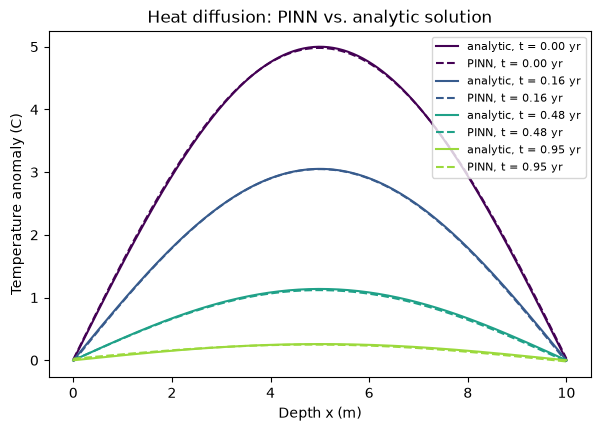

t_hat = 0.00: max abs error = 0.029 C
t_hat = 0.05: max abs error = 0.023 C
t_hat = 0.15: max abs error = 0.023 C
t_hat = 0.30: max abs error = 0.024 C


In [16]:
L = 10.0  # m
x_grid = np.linspace(0, 1, 200)
plot_times = [0.0, 0.05, 0.15, 0.3]
years_per_that = 1e8 / (365.25 * 86400)  # one unit of t_hat in years

plt.figure(figsize=(7, 4.5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(plot_times)))
for that, c in zip(plot_times, colors):
    X_plot = torch.tensor(np.stack([x_grid, np.full_like(x_grid, that)], axis=1),
                          dtype=torch.float32)
    T_pred = model_heat(X_plot).detach().numpy().ravel()
    label_t = f"t = {that * years_per_that:.2f} yr"
    plt.plot(x_grid * L, analytic_T(x_grid, that), '-', color=c,
             label=f'analytic, {label_t}')
    plt.plot(x_grid * L, T_pred, '--', color=c, label=f'PINN, {label_t}')
plt.xlabel('Depth x (m)')
plt.ylabel('Temperature anomaly (C)')
plt.title('Heat diffusion: PINN vs. analytic solution')
plt.legend(fontsize=8)
plt.show()

# Quantify the error (kept in a dict for the comparison in Section 4.4)
pinn_max_err = {}
for that in plot_times:
    X_plot = torch.tensor(np.stack([x_grid, np.full_like(x_grid, that)], axis=1),
                          dtype=torch.float32)
    T_pred = model_heat(X_plot).detach().numpy().ravel()
    pinn_max_err[that] = np.abs(T_pred - analytic_T(x_grid, that)).max()
    print(f"t_hat = {that:.2f}: max abs error = {pinn_max_err[that]:.3f} C")

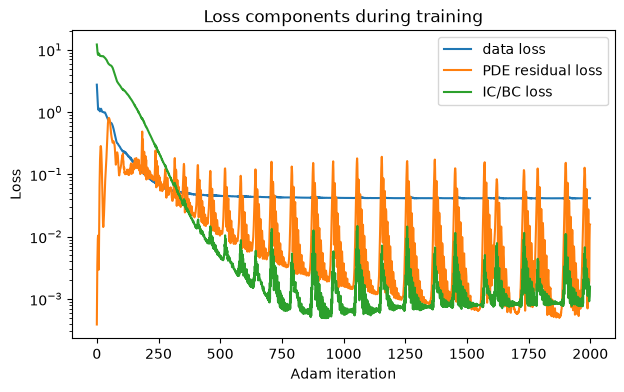

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history["data"], label='data loss')
plt.plot(history["pde"], label='PDE residual loss')
plt.plot(history["icbc"], label='IC/BC loss')
plt.yscale('log')
plt.xlabel('Adam iteration')
plt.ylabel('Loss')
plt.title('Loss components during training')
plt.legend()
plt.show()

Le PINN reproduit les profils analytiques à quelques centièmes de degré près à partir de 40 mesures ponctuelles bruitées, parce que l'EDP et les conditions aux limites portent l'essentiel de l'information. La perte de données plafonne près du plancher de bruit (le réseau ne doit pas ajuster le bruit de 0,2 °C), tandis que les pertes EDP et de conditions initiales/aux limites chutent de trois à quatre ordres de grandeur. Les pics périodiques sur ces courbes sont Adam qui dépasse brièvement puis se rattrape, spectacle courant dans l'entraînement des PINN.

L'entraînement est volontairement court ; sur votre propre machine, augmentez `n_steps` et `n_col` pour des résidus plus serrés.

**Exercice.** Mettez à zéro le poids de la perte EDP (remplacez `loss_pde` par `0 * loss_pde` dans la somme) et réentraînez. Comparez les profils à $\hat{t} = 0.3$, là où les points de données sont rares et l'anomalie petite.

```{admonition} Solution
:class: dropdown
Sans le terme EDP, le modèle devient une simple régression sur 40 points bruités, plus les contraintes de conditions initiales et aux limites. Près du profil initial, où les données sont denses relativement au signal, il paraît encore correct. Aux instants plus tardifs, le profil prédit s'écarte de la décroissance exponentielle : rien n'oblige l'intérieur du domaine à se comporter de façon diffusive, si bien que le réseau interpole le bruit à la place. L'erreur en t_hat = 0.3 est typiquement plusieurs fois plus grande. Cela reflète l'ablation de la loi de refroidissement de la section 3 : c'est le terme physique qui rend l'extrapolation digne de confiance.
```

### 4.4 La référence : 15 lignes de différences finies

La règle de ce livre est « les références avant les modèles », et le chapitre de physique n'y échappe pas. Le problème direct que nous venons de résoudre — diffusivité connue, conditions initiales et aux limites connues, solution régulière — est un cas d'école pour la numérique classique : le PINN doit donc affronter la méthode classique avant que nous le couvrions d'éloges. Le schéma le plus simple est FTCS (*forward-time, centered-space*) : placez $\hat{x}$ sur une grille, remplacez $\partial^2 T/\partial \hat{x}^2$ par la différence seconde centrée, et avancez en temps par un Euler explicite :

$$
T_i^{n+1} = T_i^n + r\,(T_{i+1}^n - 2T_i^n + T_{i-1}^n), \qquad r = \frac{\Delta \hat{t}}{\Delta \hat{x}^2}.
$$

Le schéma n'est stable que pour $r \le 1/2$ ; nous prenons $r = 0.4$. Cette contrainte est le prix d'une méthode explicite (Crank–Nicolson la supprime au prix d'une résolution tridiagonale), et sur ce problème elle ne coûte presque rien. Voici le solveur complet, chronométré :

In [18]:
# FTCS finite differences: the entire solver is the 8 lines between tic and toc
nx = 101
dx = 1.0 / (nx - 1)
dt = 0.4 * dx**2                      # explicit stability requires dt <= dx^2 / 2
nt = int(round(t_max / dt))
x_fd = np.linspace(0.0, 1.0, nx)
r = dt / dx**2
save_steps = {int(round(that / dt)): that for that in plot_times if that > 0}

tic = time.perf_counter()
T_fd = T0_heat * np.sin(np.pi * x_fd)             # initial condition
fd_snapshots = {0.0: T_fd.copy()}
for n in range(1, nt + 1):
    T_fd[1:-1] += r * (T_fd[2:] - 2 * T_fd[1:-1] + T_fd[:-2])
    if n in save_steps:                           # endpoints never updated: T = 0 C
        fd_snapshots[save_steps[n]] = T_fd.copy()
fd_seconds = time.perf_counter() - tic

print(f"FTCS: {nx} grid points, {nt} time steps, "
      f"wall-clock {fd_seconds * 1e3:.0f} ms")
print(f"\n{'t_hat':>6} {'FD max err (C)':>16} {'PINN max err (C)':>18}")
for that in plot_times:
    fd_err = np.abs(fd_snapshots[that] - analytic_T(x_fd, that)).max()
    print(f"{that:6.2f} {fd_err:16.2e} {pinn_max_err[that]:18.3f}")
print(f"\nwall-clock: FD {fd_seconds * 1e3:.0f} ms vs. PINN training "
      f"{pinn_train_seconds:.0f} s -> the PINN is "
      f"{pinn_train_seconds / fd_seconds:.0f}x slower")

FTCS: 101 grid points, 7500 time steps, wall-clock 20 ms

 t_hat   FD max err (C)   PINN max err (C)
  0.00         0.00e+00              0.029
  0.05         1.73e-04              0.023
  0.15         1.94e-04              0.023
  0.30         8.83e-05              0.024

wall-clock: FD 20 ms vs. PINN training 14 s -> the PINN is 698x slower


Le verdict est sans appel. Le solveur en différences finies termine en 20 ms environ et reproduit la solution analytique à environ $2 \times 10^{-4}$ °C près ; le PINN a eu besoin de 14 s d'entraînement pour parvenir à 0,03 °C près. Sur ce problème direct, le solveur classique l'emporte d'un facteur d'environ 750 en vitesse et de deux ordres de grandeur en précision, sans taux d'apprentissage, sans architecture et sans graine. C'est la lecture honnête de la section 4.3, et elle se généralise : quand les coefficients, la condition initiale et les conditions aux limites sont connus et qu'une discrétisation standard existe, employez la discrétisation standard. La cause du PINN doit se plaider ailleurs.

Deux choses, cependant, que le solveur en différences finies n'a pas faites. Il n'a jamais touché aux 40 mesures intérieures bruitées, parce qu'un solveur direct n'a aucune case où loger des observations dispersées. Et il a exigé $k$ en entrée. Ces deux lacunes pointent vers le même endroit, et c'est là que nous allons.

### 4.5 Le problème inverse : retrouver la diffusivité

La section 5 soutiendra que les problèmes inverses sont le premier régime où les PINN restent le bon outil. En voici la démonstration, sur les données que nous avons déjà. Faisons comme si la diffusivité était inconnue. En unités adimensionnées, la valeur du générateur vaut exactement $\hat{k} = 1$, puisque l'adimensionnement a employé le vrai $k = 10^{-6}\ \mathrm{m^2/s}$ ; le modèle, lui, l'ignore. Nous initialisons un $\hat{k}$ entraînable à 0,2, cinq fois trop bas, et laissons l'optimiseur le retrouver à partir des mêmes 40 échantillons bruités.

La modification de la boucle d'entraînement de la section 4.2 tient en cinq lignes, marquées `(1)`–`(4)` ci-dessous : $\hat{k}$ devient un `nn.Parameter` (stocké comme $\log \hat{k}$ pour rester positif), il rejoint la liste de paramètres de l'optimiseur, et le résidu devient $\partial T_\theta/\partial \hat{t} - \hat{k}\, \partial^2 T_\theta/\partial \hat{x}^2$. Tout le reste est inchangé. L'information circule ainsi : la condition initiale fixe la forme de l'anomalie, les 40 échantillons fixent la vitesse à laquelle elle décroît, et l'EDP relie ce taux de décroissance à $\hat{k}$.

In [19]:
model_inv = HeatPINN().to(DEVICE)
log_k = nn.Parameter(torch.log(torch.tensor(0.2)))    # (1) trainable k_hat, start 5x too low
optimizer_inv = optim.Adam(list(model_inv.parameters()) + [log_k],  # (2) k joins the optimizer
                           lr=2e-3)

k_history = []
tic = time.perf_counter()
for step in range(n_steps):
    optimizer_inv.zero_grad()
    loss_data = mse(model_inv(X_data), y_data)
    T_c = model_inv(X_col)
    g = grad(T_c, X_col)[0]
    T_x, T_t = g[:, 0:1], g[:, 1:2]
    T_xx = grad(T_x, X_col)[0][:, 0:1]
    loss_pde = torch.mean((T_t - torch.exp(log_k) * T_xx) ** 2)     # (3) k in the residual
    loss_icbc = (mse(model_inv(X_ic), y_ic)
                 + torch.mean(model_inv(X_b0) ** 2)
                 + torch.mean(model_inv(X_b1) ** 2))
    (loss_data + loss_pde + loss_icbc).backward()
    optimizer_inv.step()
    k_history.append(torch.exp(log_k).item())                       # (4) track the estimate
    if step % 400 == 0 or step == n_steps - 1:
        print(f"step {step:4d}  k_hat = {k_history[-1]:.3f}")
inv_seconds = time.perf_counter() - tic

k_rec = k_history[-1]
print(f"\nrecovered k_hat = {k_rec:.3f}  (generator truth 1.0, "
      f"error {abs(k_rec - 1.0) * 100:.1f}%)")
print(f"physical units: k = {k_rec * 1e-6:.2e} m^2/s  (truth 1.00e-06)")
print(f"wall-clock: {inv_seconds:.0f} s")

step    0  k_hat = 0.200


step  400  k_hat = 0.460


step  800  k_hat = 0.728


step 1200  k_hat = 0.875


step 1600  k_hat = 0.947


step 1999  k_hat = 0.981

recovered k_hat = 0.981  (generator truth 1.0, error 1.9%)
physical units: k = 9.81e-07 m^2/s  (truth 1.00e-06)
wall-clock: 14 s


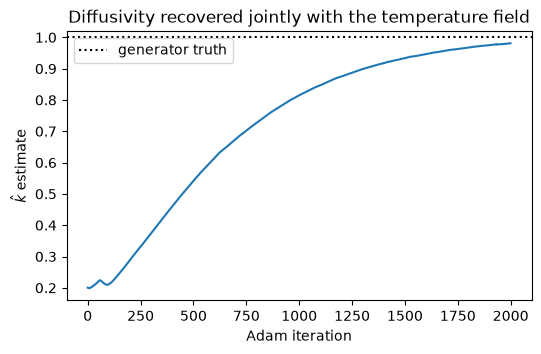

In [20]:
plt.figure(figsize=(6, 3.5))
plt.plot(k_history)
plt.axhline(1.0, color='k', ls=':', label='generator truth')
plt.xlabel('Adam iteration')
plt.ylabel(r'$\hat{k}$ estimate')
plt.title('Diffusivity recovered jointly with the temperature field')
plt.legend()
plt.show()

La diffusivité retrouvée tombe à 2 % près de la vérité du générateur, à partir de 40 mesures ponctuelles bruitées et de rien de maillé. Soyons clairs sur ce qu'est cette exécution : un calage, aussi appelé calage historique (*history matching*). Le solveur en différences finies de la section 4.4 ne peut pas le faire seul, puisqu'il exige $k$ en entrée. La voie classique enveloppe le solveur dans une boucle d'optimisation externe qui le relance pour chaque $k$ candidat ; en hydrogéologie, c'est ce que fait PEST autour d'un modèle MODFLOW quand on cale la conductivité hydraulique sur des relevés de puits épars. Le PINN fusionne les deux boucles : un seul entraînement ajuste le champ de température et inverse le paramètre en même temps, et la même astuce s'étend à de nombreuses inconnues (un $k(\hat{x})$ variable dans l'espace peut être un second petit réseau). Des données ponctuelles éparses et bruitées, plus une équation de confiance, plus des coefficients inconnus : voilà le régime où la machinerie supplémentaire est rentable.

### 4.6 Casser le PINN : le déséquilibre des poids de perte

Jusqu'ici la perte composite s'est bien comportée parce que ses trois termes se trouvaient à des échelles comparables ; des poids égaux ont simplement fonctionné. C'est de la chance, pas une loi, et l'avertissement de la section 5 sur l'équilibrage des pertes mérite le traitement réservé aux entraînements défaillants du carnet 4.5 : montrer la défaillance, lire les symptômes, nommer le remède.

L'exercice de la section 4.3 supprimait le terme physique et regardait le modèle dégénérer en une régression bruitée. Ici, nous cassons l'équilibre dans l'autre sens : le terme physique noie les données et la condition initiale. L'exécution ci-dessous reprend la section 4.2 avec un seul changement, `w_pde = 1e4` sur le résidu de l'EDP. Observez le total affiché : il continue de baisser, comme si l'entraînement se passait bien.

In [21]:
model_bad = HeatPINN().to(DEVICE)
optimizer_bad = optim.Adam(model_bad.parameters(), lr=2e-3)
w_pde = 1e4                       # the only change from Section 4.2

history_bad = {"data": [], "pde": [], "icbc": []}
for step in range(n_steps):
    optimizer_bad.zero_grad()
    loss_data = mse(model_bad(X_data), y_data)
    T_c = model_bad(X_col)
    g = grad(T_c, X_col)[0]
    T_x, T_t = g[:, 0:1], g[:, 1:2]
    T_xx = grad(T_x, X_col)[0][:, 0:1]
    loss_pde = torch.mean((T_t - T_xx) ** 2)
    loss_icbc = (mse(model_bad(X_ic), y_ic)
                 + torch.mean(model_bad(X_b0) ** 2)
                 + torch.mean(model_bad(X_b1) ** 2))
    total = loss_data + w_pde * loss_pde + loss_icbc
    total.backward()
    optimizer_bad.step()
    for key, val in zip(("data", "pde", "icbc"), (loss_data, loss_pde, loss_icbc)):
        history_bad[key].append(val.item())
    if step % 400 == 0 or step == n_steps - 1:
        print(f"step {step:4d}  total {total.item():8.3f}  data {loss_data.item():.3f}  "
              f"pde {loss_pde.item():.5f}  ic/bc {loss_icbc.item():.3f}")

step    0  total   96.174  data 2.569  pde 0.00819  ic/bc 11.750


step  400  total    9.546  data 1.123  pde 0.00000  ic/bc 8.419


step  800  total    9.476  data 1.111  pde 0.00000  ic/bc 8.361


step 1200  total    9.482  data 1.114  pde 0.00000  ic/bc 8.365


step 1600  total    9.499  data 1.118  pde 0.00000  ic/bc 8.378


step 1999  total    9.215  data 1.066  pde 0.00000  ic/bc 8.134


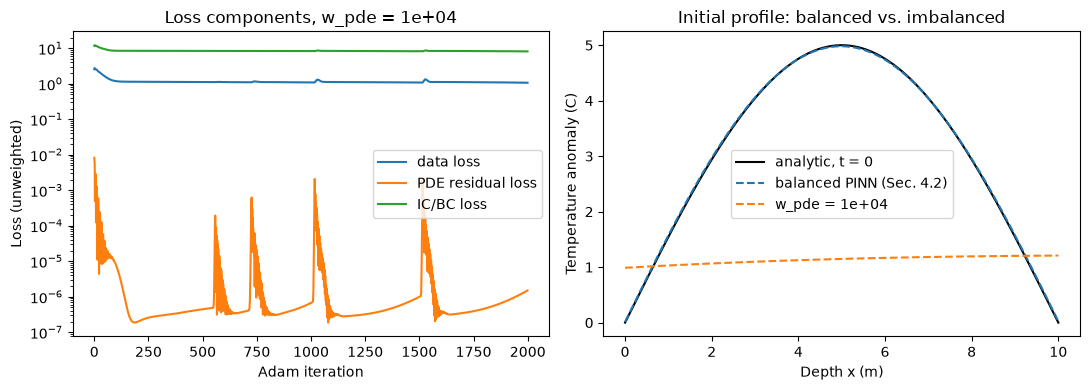

max error at t_hat = 0: broken run 3.85 C, balanced run 0.029 C  (signal amplitude 5.0 C)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_bad["data"], label='data loss')
axes[0].plot(history_bad["pde"], label='PDE residual loss')
axes[0].plot(history_bad["icbc"], label='IC/BC loss')
axes[0].set_yscale('log')
axes[0].set_xlabel('Adam iteration')
axes[0].set_ylabel('Loss (unweighted)')
axes[0].set_title(f'Loss components, w_pde = {w_pde:.0e}')
axes[0].legend()

X_plot0 = torch.tensor(np.stack([x_grid, np.zeros_like(x_grid)], axis=1),
                       dtype=torch.float32)
axes[1].plot(x_grid * L, analytic_T(x_grid, 0.0), 'k-', label='analytic, t = 0')
axes[1].plot(x_grid * L, model_heat(X_plot0).detach().numpy().ravel(), '--',
             label='balanced PINN (Sec. 4.2)')
axes[1].plot(x_grid * L, model_bad(X_plot0).detach().numpy().ravel(), '--',
             label=f'w_pde = {w_pde:.0e}')
axes[1].set_xlabel('Depth x (m)')
axes[1].set_ylabel('Temperature anomaly (C)')
axes[1].set_title('Initial profile: balanced vs. imbalanced')
axes[1].legend()
plt.tight_layout()
plt.show()

err_bad = np.abs(model_bad(X_plot0).detach().numpy().ravel()
                 - analytic_T(x_grid, 0.0)).max()
print(f"max error at t_hat = 0: broken run {err_bad:.2f} C, "
      f"balanced run {pinn_max_err[0.0]:.3f} C  (signal amplitude {T0_heat} C)")

La perte totale baisse et la réponse ne vaut rien. Cette combinaison est la signature d'un déséquilibre des pertes, et elle est invisible tant que vous ne journalisez pas les composantes séparément. Lisez-les, pas le total : après quelques centaines de pas, le résidu de l'EDP est plaqué sous $10^{-5}$, tandis que la perte de données stagne près de 1 (bien au-dessus du plancher de bruit de 0,04 de la section 4.2) et que la perte de conditions initiales/aux limites bloque près de 8, du même ordre que les 12,5 qu'obtiendrait un réseau sortant zéro partout (la moyenne de $(5\sin\pi\hat{x})^2$). Le réseau a trouvé une solution quasi triviale : $T \approx 0$ satisfait exactement l'équation de la chaleur et les conditions aux limites, si bien que l'objectif pondéré récompense le fait de rester près d'elle, et que tout mouvement vers le vrai profil initial est puni par le terme dominant avant d'avoir pu payer. Le profil en $\hat{t}=0$ rate l'anomalie de 5 °C d'environ 4 °C.

Le remède est l'équilibre que nous avions déjà : à poids égaux, la même architecture et les mêmes 2000 pas atteignaient 0,03 °C à la section 4.2. Quand aucune pondération fixe ne fonctionne, parce que les termes ont des échelles réellement différentes, les gestes standard consistent à normaliser chaque terme par sa valeur initiale, à régler les poids sur une métrique de validation réservée, ou à employer un schéma de pondération adaptatif (Karniadakis et al., 2021) ; un entraînement plus long et des couches plus larges n'aident que si le déséquilibre est léger. L'habitude à retenir : tracez toujours les composantes de la perte séparément. Une courbe unique de perte totale cache exactement cette défaillance.

**Exercice (biais spectral).** L'autre mode de défaillance que nomme la section 5 est le biais spectral. Ajoutez un mode de plus haute fréquence à la condition initiale :

$$
T(\hat{x}, 0) = 5 \sin(\pi \hat{x}) + 2 \sin(7\pi \hat{x}),
$$

dont la solution analytique ajoute $2\sin(7\pi\hat{x})\,e^{-49\pi^2 \hat{t}}$ à la référence à mode unique. Régénérez `y_ic` et les 40 échantillons de données à partir de la solution à deux modes, réentraînez le PINN de la section 4.2 (poids égaux), et relancez le solveur FTCS de la section 4.4 avec le nouveau profil initial. Comparez les deux à la solution analytique en $\hat{t} = 0$.

```{admonition} Solution
:class: dropdown
Le solveur FTCS traite le nouveau mode sans changer une ligne de code : à nx = 101, le septième mode dispose d'environ 28 points de grille par longueur d'onde. Le PINN, non. Après les mêmes 2000 pas, son profil initial est le premier mode lissé, ondulations aplaties : la perte de condition initiale bloque près de 2 (le carré moyen du mode manquant, 2^2/2), et l'erreur maximale en t_hat = 0 vaut environ 2 degrés, soit toute l'amplitude du mode que le réseau a refusé d'apprendre. Voilà le biais spectral : les MLP à tanh ajustent d'abord les basses fréquences et les hautes fréquences lentement, quand ils y parviennent. Remèdes, par effort croissant : entraîner beaucoup plus longtemps, élargir les couches, ou donner au réseau des entrées en caractéristiques de Fourier (plongements sin/cos de x_hat), le remède standard. Pour la diffusion, l'enjeu est faible : le septième mode décroît en e^(-49 pi^2 t_hat) et disparaît physiquement en quelques jours. Pour les équations d'onde, il n'y a pas cette clémence, car les hautes fréquences sont le signal.
```

## 5. Où en sont les PINN en 2026

Les PINN ne sont plus une nouveauté, et leurs modes de défaillance sont bien documentés ; deux d'entre eux se trouvent désormais dans ce carnet. L'équilibrage des pertes est un problème de réglage tenace : un mauvais équilibre fait converger l'entraînement vers une solution qui satisfait un terme et ignore les autres, et la section 4.6 l'a montré sur notre propre problème, où un facteur $10^4$ sur le terme physique a produit un réseau coincé près de la solution triviale nulle, ratant l'anomalie de 5 °C d'environ 4 °C pendant que sa perte totale continuait de baisser. Les MLP standard portent aussi un biais spectral vers les fonctions lisses et de basse fréquence : ils apprennent vite les solutions régulières et lentement — quand ils y parviennent — les structures oscillantes ou à petite échelle (Karniadakis et al., 2021) ; l'exercice de la section 4.6 amène un MLP à tanh à aplatir une ondulation de septième mode que le solveur en différences finies résout sans aucune modification. Les EDP raides, les fronts abrupts et les échelles de temps très séparées aggravent les deux problèmes, car le résidu varie alors sur des ordres de grandeur à travers le domaine et aucune pondération fixe n'est juste partout.

La première règle d'usage est négative : ne résolvez pas un problème direct propre avec un PINN. La section 4.4 y a mis des chiffres. Quinze lignes de FTCS ont battu le PINN entraîné d'un facteur d'environ 750 en temps de calcul et de deux ordres de grandeur en précision, sans aucun hyperparamètre à régler. Quand les coefficients et les conditions aux limites sont connus et qu'une discrétisation standard existe, le solveur classique gagne. Et pour le problème voisin de la construction de modèles de substitution rapides évalués de nombreuses fois, les opérateurs neuronaux ont largement pris le relais : le *Fourier Neural Operator* (Li et al., 2021) et DeepONet (Lu et al., 2021) apprennent l'*opérateur solution*, l'application qui va d'une condition initiale, d'une condition aux limites ou d'un champ de coefficients vers la solution, si bien qu'après entraînement sur de nombreuses paires de simulations un nouveau cas coûte quelques millisecondes, là où un PINN se réentraînerait de zéro. Pour les études paramétriques, la quantification d'incertitude et la prévision opérationnelle, c'est cet outil-là qui sert.

Les PINN gardent malgré tout leur utilité dans deux régimes, tous deux désormais démontrés plutôt qu'affirmés. Le premier est celui des problèmes inverses : la section 4.5 a fait de la diffusivité un paramètre entraînable et l'a retrouvée à 2 % près à partir des 40 échantillons bruités, l'EDP jouant le rôle du modèle direct à l'intérieur d'une régression (Raissi et al., 2019). C'est de l'inversion conjointe, le motif PEST-autour-de-MODFLOW du calage hydrogéologique replié en une seule boucle d'entraînement. Le second est le régime pauvre en données que représentent ces mêmes 40 points : des observations dispersées et bruitées, plus une équation gouvernante de confiance, et aucune bibliothèque de simulations sur laquelle entraîner un opérateur. Un solveur direct n'a aucune case pour de telles données ; le PINN les traite comme un terme de perte de plus. Ces deux situations sont courantes en géosciences, et c'est pourquoi la méthode reste dans la boîte à outils (Karniadakis et al., 2021).

## Références

* Raissi, M., Perdikaris, P., and Karniadakis, G. E. (2019). Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. *Journal of Computational Physics*, 378, 686-707.
* Karniadakis, G. E., Kevrekidis, I. G., Lu, L., Perdikaris, P., Wang, S., and Yang, L. (2021). Physics-informed machine learning. *Nature Reviews Physics*, 3, 422-440.
* Li, Z., Kovachki, N., Azizzadenesheli, K., Liu, B., Bhattacharya, K., Stuart, A., and Anandkumar, A. (2021). Fourier neural operator for parametric partial differential equations. *International Conference on Learning Representations (ICLR)*.
* Lu, L., Jin, P., Pang, G., Zhang, Z., and Karniadakis, G. E. (2021). Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. *Nature Machine Intelligence*, 3, 218-229.

## Résumé

* Un PINN ajoute à la perte d'entraînement le résidu d'une équation gouvernante, évalué par différentiation automatique en des points de collocation.
* Sur l'ablation de la loi de refroidissement, seul le terme physique a produit une extrapolation correcte au-delà des données ; la régularisation L2, non.
* Sur l'équation de la chaleur 1-D, un MLP à tanh de 3 couches a retrouvé le mode diffusif analytique à partir de 40 échantillons bruités, plus l'EDP et les conditions aux limites.
* La référence classique a remporté haut la main le problème direct : 15 lignes de FTCS ont été environ 750 fois plus rapides et deux ordres de grandeur plus précises que le PINN (section 4.4).
* Faire de la diffusivité un paramètre entraînable a transformé la même boucle en une inversion conjointe qui a retrouvé $\hat{k}$ à 2 % près à partir des 40 échantillons bruités, un calage que le solveur direct ne peut pas faire seul (section 4.5).
* Un poids de $10^4$ sur la perte physique a donné une perte totale décroissante et une réponse fausse ; la défaillance n'est visible que sur les courbes de perte par terme, alors tracez toujours les composantes (section 4.6).
* En 2026 : les solveurs classiques pour les problèmes directs propres, les opérateurs neuronaux (FNO, DeepONet) pour les modèles de substitution paramétriques, les PINN pour les problèmes inverses et pauvres en données.